In [2]:
# rates with HMM vs TP 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, medfilt
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit


F = 0
filename = f"langevinSimulation_F{F}.npz"
loaded = np.load(filename)
my_array = loaded["data"]         # supponendo shape (N,2) colonne [Time, Position_x]
df = pd.DataFrame(my_array, columns=["Time", "Position_x"])

print(df.shape)
print(df.head())


t_start = 0     
t_end = 60
dt = 0.0005
idx_start = int(t_start / dt)
idx_end = int(t_end / dt)

t = df["Time"].values[idx_start:idx_end]
x = df["Position_x"].values[idx_start:idx_end]


(6000000, 2)
     Time  Position_x
0  0.0000    0.000000
1  0.0005    1.116071
2  0.0010   -0.233595
3  0.0015    0.041861
4  0.0020    0.041737


In [3]:
file = "Talin_7p7_pN.txt"
# "Talin_temperature.txt" con dt = 8.494e-4 , "Talin_fragment.txt"

data = np.loadtxt(file , skiprows=1)
t = data[:, 0]
x = data[:, 1]

dt = 8.494e-4 

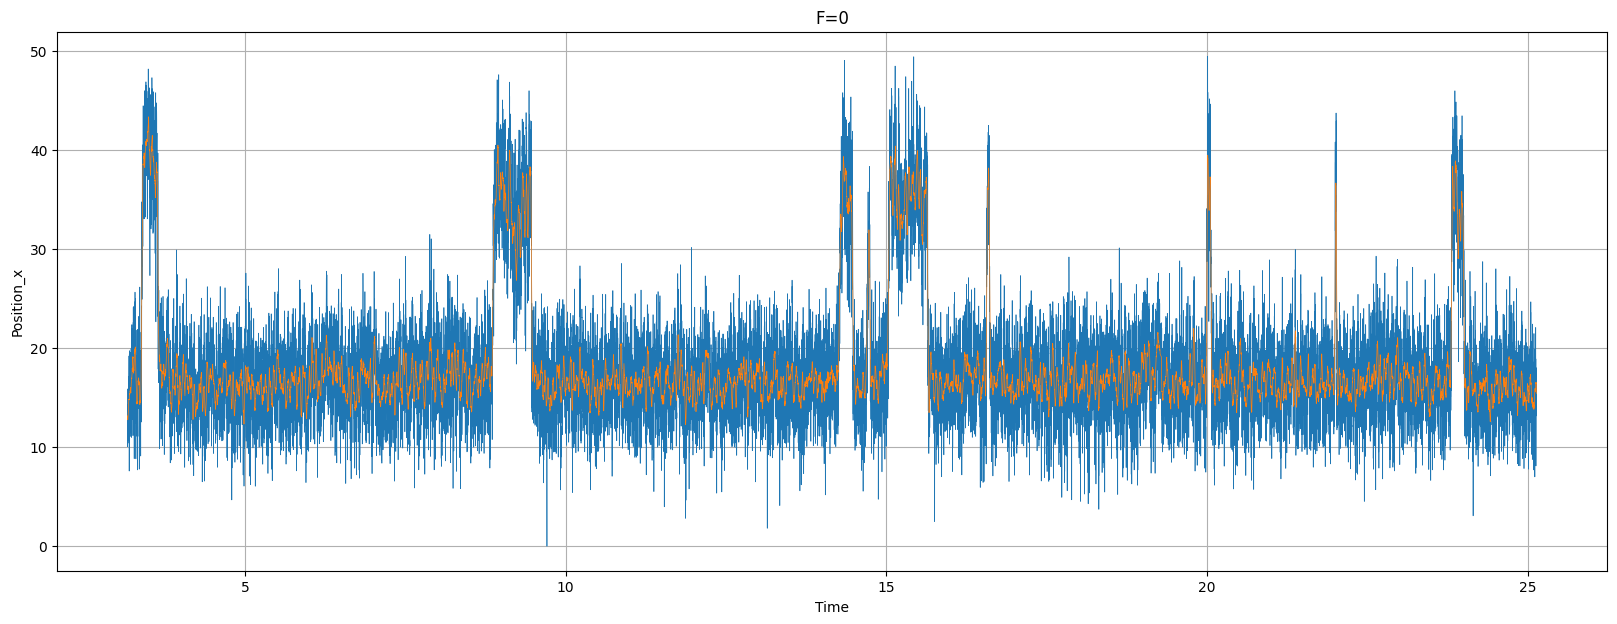

In [4]:
# N = min(len(t), 90000)   # evita errore se la traccia è più corta
plt.figure(figsize=(20,7))
plt.plot(t[0:30000], x[0:30000], lw=0.5)

window_length =61
poly_order = 3 
x_smooth = savgol_filter(x, window_length, poly_order)
plt.plot(t[0:30000], x_smooth[0:30000], lw=0.5)

plt.xlabel('Time')
plt.ylabel('Position_x')
plt.title(f'F={F}')
plt.grid(True)
plt.show()


In [5]:
X  = x_smooth.reshape(-1,1)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=30)
kmeans.fit(X)
init_means = kmeans.cluster_centers_   # stima delle medie dei due stati

print("Medie iniziali trovate da KMeans:", init_means.ravel())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=300, random_state=30, init_params='')  #dati 1D -> diag
model.means_ = scaler.transform(init_means)  
# model.covars_ = np.array([[0.1], [0.1]])
model.fit(X_scaled)   # array di lunghezza n_samples
states = model.predict(X_scaled)

# ordino gli stati in base alla media 
means_real = np.array([X[states == s].mean() for s in range(2)])
order = np.argsort(means_real)
states_ordered = np.zeros_like(states)
for new_idx, old_idx in enumerate(order):
    states_ordered[states == old_idx] = new_idx
states = states_ordered  # sovrascrivi
print("Medie reali ordinate:", means_real[order])

print (states)
# states = [0,0,1,1,0,1,..]


Medie iniziali trovate da KMeans: [17.74633196 36.95771508]
Medie reali ordinate: [17.70412936 36.721311  ]
[0 0 0 ... 1 1 1]


In [6]:
def get_dwell_counts(states_seq):
    curr = states_seq[0]
    count = 1
    dwell_by_state = {0: [], 1: []}  # solo fold/unfold

    for s in states_seq[1:]:
        if s == curr:
            count += 1
        else:
            # salva solo se era uno stato utile
            if curr in dwell_by_state:
                dwell_by_state[curr].append(count)
            curr = s
            count = 1
    if curr in dwell_by_state:
        dwell_by_state[curr].append(count)

    return dwell_by_state

dt = 0.0005
dwell_counts = get_dwell_counts(states)
dwell_secs = {s: np.array(dwell_counts[s]) * dt for s in dwell_counts}
for s in dwell_secs:
    print(f"State {s}: n_dwell = {len(dwell_secs[s])}, mean_dwell = {dwell_secs[s].mean():.4g} s")


State 0: n_dwell = 1641, mean_dwell = 1.2 s
State 1: n_dwell = 1641, mean_dwell = 0.2976 s


In [7]:
rates = {}
for s, arr in dwell_secs.items():
    mean_tau = arr.mean()  # tempo medio di permanenza nello stato 
    std_tau = arr.std(ddof=1) if len(arr)>1 else 0.0
    rate = 1.0 / mean_tau
    std_mean = std_tau / np.sqrt(len(arr)) if len(arr)>1 else 0.0
    rate_err = std_mean / (mean_tau**2)
    rates[s] = (rate, rate_err)
    print(f"State {s}: k = {rate:.4g} ± {rate_err:.4g} s^-1")


State 0: k = 0.8331 ± 0.02215 s^-1
State 1: k = 3.36 ± 0.08799 s^-1


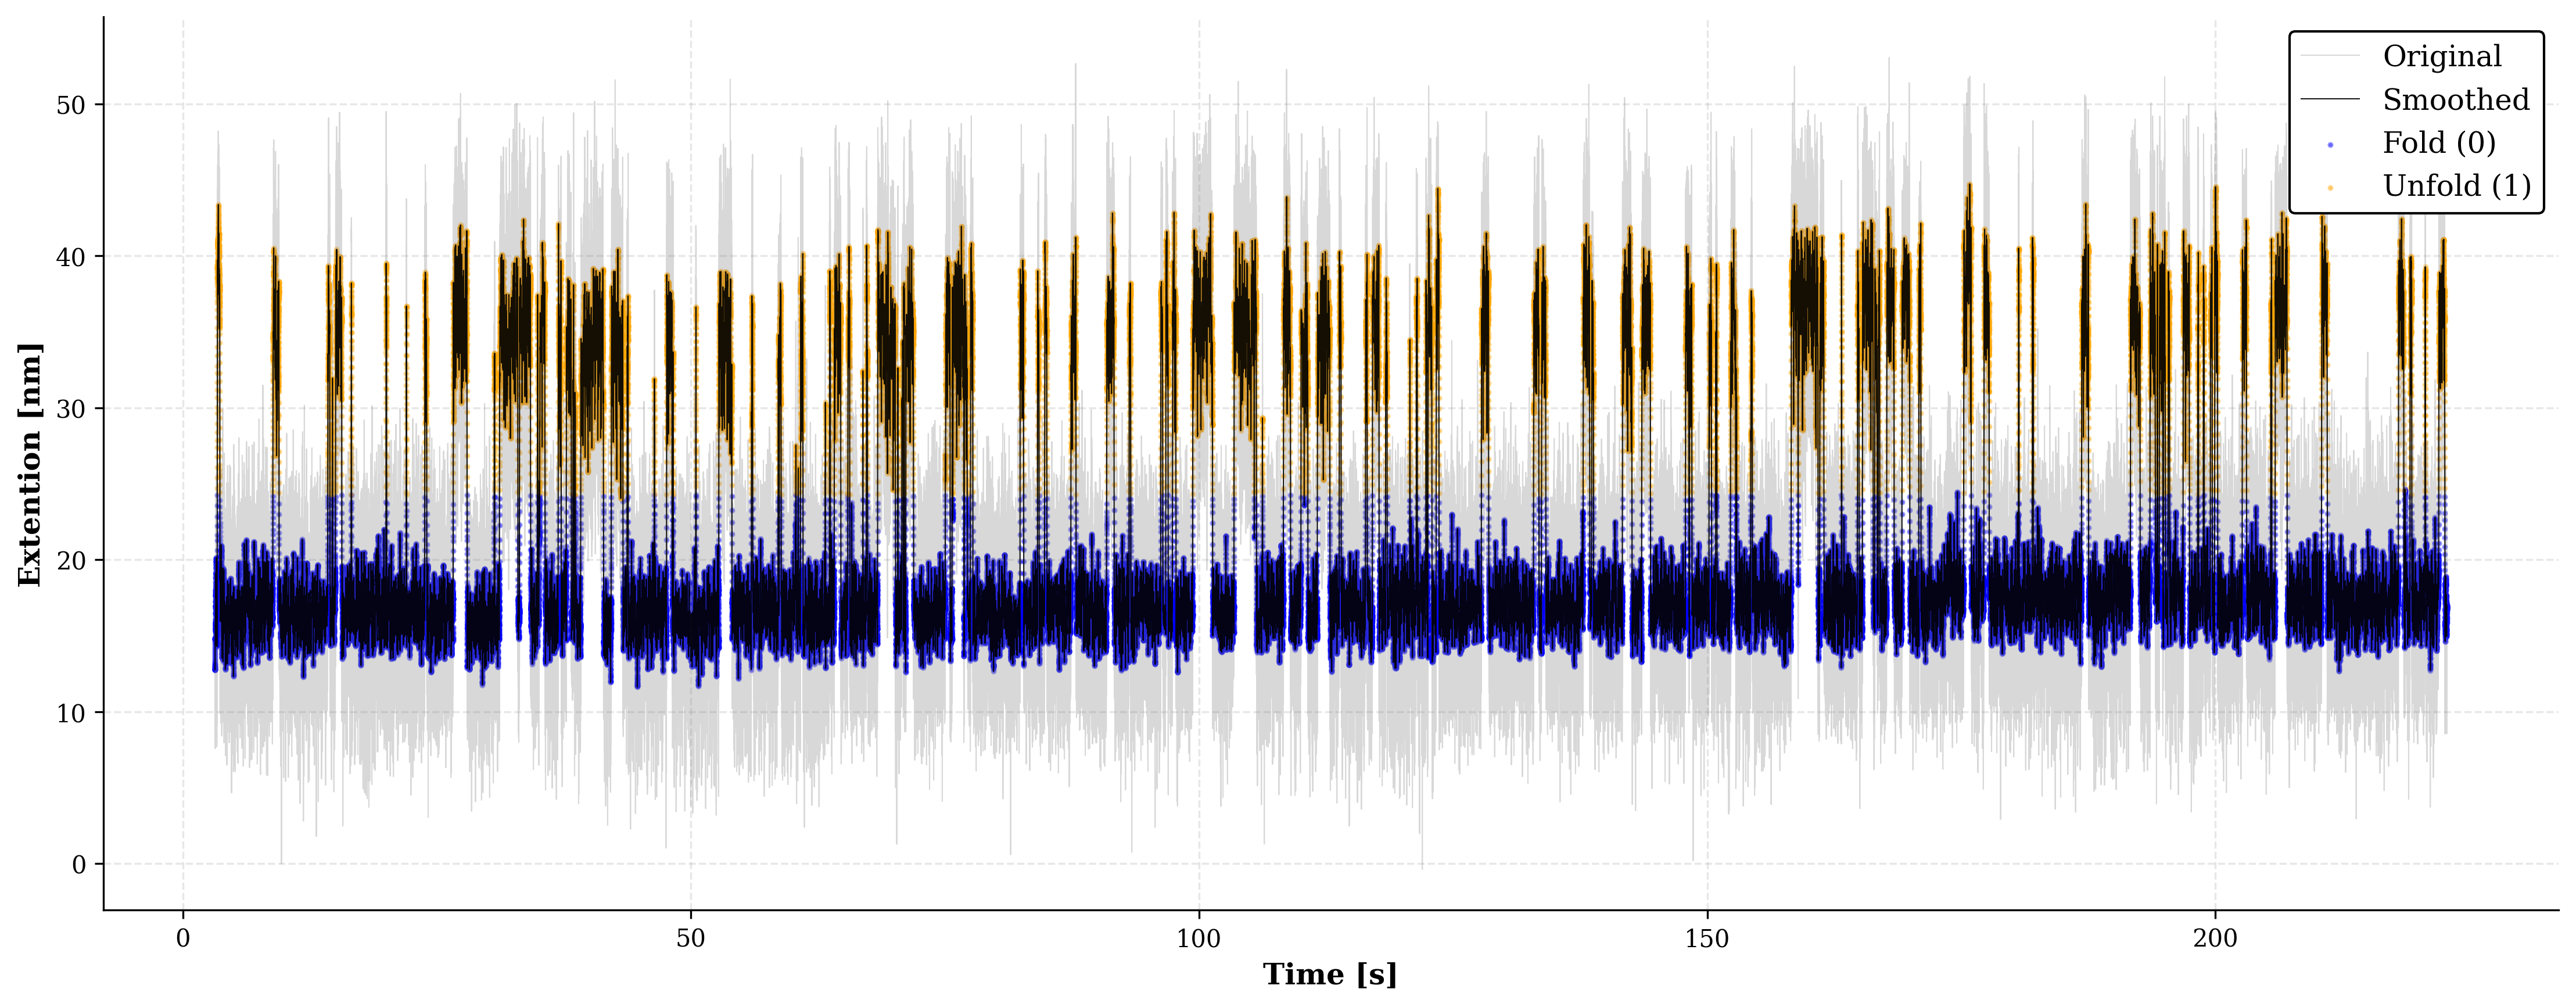

In [30]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

start_idx = 0
end_idx = 300000

t_plot = t[start_idx:end_idx]
x_plot = x[start_idx:end_idx]
x_smooth_plot = x_smooth[start_idx:end_idx]
states_plot = states[start_idx:end_idx]

mask_fold = (states_plot == 0)
mask_trans = (states_plot == 1)

fig, ax1 = plt.subplots(figsize=(15, 6), dpi=300)

ax1.plot(t_plot, x_plot, color="gray", lw=0.5, alpha=0.3, label="Original")
ax1.plot(t_plot, x_smooth_plot, color="black", lw=0.5, alpha=0.9, label="Smoothed")

ax1.scatter(t_plot[mask_fold], x_smooth_plot[mask_fold], s=2, color="blue", alpha=0.4, label="Fold (0)")
ax1.scatter(t_plot[mask_trans], x_smooth_plot[mask_trans], s=2, color="orange", alpha=0.4, label="Unfold (1)")

ax1.set_xlabel("Time [s]", fontweight='bold')
ax1.set_ylabel("Extention [nm]", fontweight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.legend(loc="upper right", frameon=True, facecolor='white', framealpha=1, edgecolor='black', fontsize=12)

plt.tight_layout()
plt.savefig("HMM_states.pdf")
plt.show()


State 0:
  λ = 0.8945 ± 0.01126 s⁻¹
  τ = 1.118 s


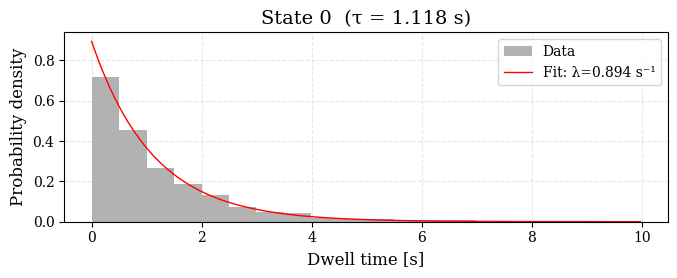


State 1:
  λ = 3.808 ± 0.07636 s⁻¹
  τ = 0.2626 s


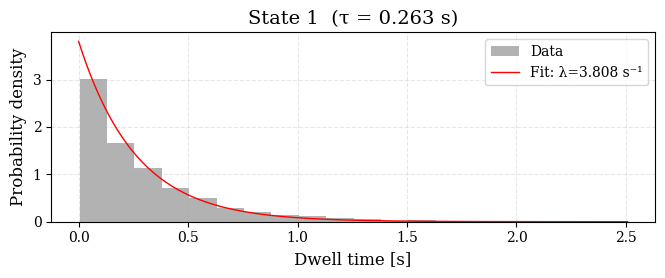

In [32]:
def exp_pdf(t, lam):
    """PDF esponenziale: p(t) = λ * exp(-λt)"""
    return lam * np.exp(-lam * t)

bins = 20

for state in [0, 1]:  
    data = dwell_secs[state]

    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    p0 = [1 / np.mean(data)]
    popt, pcov = curve_fit(exp_pdf, bin_centers, counts, p0=p0, maxfev=10000)
    lam = popt[0]
    lam_std = np.sqrt(np.diag(pcov))[0]

    tau = 1 / lam

    print(f"\nState {state}:")
    print(f"  λ = {lam:.4g} ± {lam_std:.4g} s⁻¹")
    print(f"  τ = {tau:.4g} s")

    plt.figure(figsize=(7, 3))
    plt.hist(data, bins=bins, density=True, alpha=0.6, label="Data", color="gray")
    t_fit = np.linspace(0, bin_edges[-1], 300)
    plt.plot(t_fit, exp_pdf(t_fit, lam), "r-", lw=1.0, label=f"Fit: λ={lam:.3f} s⁻¹")
    plt.xlabel("Dwell time [s]")
    plt.ylabel("Probability density")
    plt.title(f"State {state}  (τ = {tau:.3f} s)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [33]:
rate_df = pd.DataFrame(columns=['force', 'kramer_f', 'kramer_u', 'mfpt_f', 'mfpt_u', 'hmm_f', 'hmm_u' ])
rate_df.loc[len(rate_df)] = [0.25,  1.321004,   4.746486,	1.227364, 3.793793, 1.949, 5.942 ]
rate_df.loc[len(rate_df)] = [0.5, 0.659542, 8.513434, 0.648187, 6.180612,   1.6, 8.4 ]
rate_df.loc[len(rate_df)] = [0.0, 2.563005,	2.563005,   2.212954,	2.212954, 2.82, 3.0]
rate_df.loc[len(rate_df)] = ["Talin Drift 0", None,	None,   None,	None, 2.68, 0.66]
rate_df.loc[len(rate_df)] = ["Talin7pN ", None,	None,   None,	None, 3.36, 0.83]


rate_df

C:\Users\bulga\AppData\Local\Temp\ipykernel_8280\1506652700.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rate_df.loc[len(rate_df)] = ["Talin Drift 0", None,	None,   None,	None, 2.68, 0.66]
C:\Users\bulga\AppData\Local\Temp\ipykernel_8280\1506652700.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rate_df.loc[len(rate_df)] = ["Talin7pN ", None,	None,   None,	None, 3.36, 0.83]


,force,kramer_f,kramer_u,mfpt_f,mfpt_u,hmm_f,hmm_u
0,0.25,1.321004,4.746486,1.227364,3.793793,1.949,5.942
1,0.5,0.659542,8.513434,0.648187,6.180612,1.600,8.400
2,0.0,2.563005,2.563005,2.212954,2.212954,2.820,3.000
3,Talin Drift 0,NaN,NaN,NaN,NaN,2.680,0.660
4,Talin7pN,NaN,NaN,NaN,NaN,3.360,0.830
